In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re
import ast
from collections import Counter

# ── plot style ──────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 130, "figure.figsize": (12, 5)})

print("✅  Libraries loaded")


✅  Libraries loaded


In [2]:
df = pd.read_csv("linkedin-jobs-usa.csv")
print(f"Shape: {df.shape}")
df.head(3)


Shape: (2845, 9)


,title,company,description,onsite_remote,salary,location,criteria,posted_date,link
0,Data Analyst - Recent Graduate,PayPal,"At PayPal (NASDAQ: PYPL), we believe that ever...",onsite,NaN,Buffalo-Niagara Falls Area,"[{'Seniority level': 'Not Applicable'}, {'Empl...",2022-11-22,https://www.linkedin.com/jobs/view/data-analys...
1,Data Analyst - Recent Graduate,PayPal,"At PayPal (NASDAQ: PYPL), we believe that ever...",onsite,NaN,"San Jose, CA","[{'Seniority level': 'Not Applicable'}, {'Empl...",2022-11-22,https://www.linkedin.com/jobs/view/data-analys...
2,Data Analyst,PayPal,"At PayPal (NASDAQ: PYPL), we believe that ever...",onsite,NaN,"Texas, United States","[{'Seniority level': 'Not Applicable'}, {'Empl...",2022-11-17,https://www.linkedin.com/jobs/view/data-analys...


In [3]:
# ── basic info ──────────────────────────────────────────────────────────────
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())


title            object
company          object
description      object
onsite_remote    object
salary           object
location         object
criteria         object
posted_date      object
link             object
dtype: object

Missing values:
title               0
company             0
description         0
onsite_remote       0
salary           1916
location            0
criteria            0
posted_date         0
link                0
dtype: int64


In [4]:
# ── clean column names & types ──────────────────────────────────────────────
df.columns = df.columns.str.strip()

# Parse posted_date
df['posted_date'] = pd.to_datetime(df['posted_date'], errors='coerce')

# Normalise onsite_remote
df['work_type'] = df['onsite_remote'].str.strip().str.lower().fillna('unknown')

# Normalise title
df['title_clean'] = df['title'].str.strip().str.title()

# Extract state from location
def extract_state(loc):
    if pd.isna(loc):
        return 'Unknown'
    # "City, ST" pattern
    m = re.search(r',\s*([A-Z]{2})$', str(loc))
    if m:
        return m.group(1)
    # "State, United States" pattern
    m2 = re.search(r'^([^,]+),\s*United States', str(loc))
    if m2:
        return m2.group(1).strip()
    return 'Unknown'

df['state'] = df['location'].apply(extract_state)

print("✅  Cleaning done")
df[['title_clean', 'work_type', 'state', 'posted_date']].head()


✅  Cleaning done


,title_clean,work_type,state,posted_date
0,Data Analyst - Recent Graduate,onsite,Unknown,2022-11-22
1,Data Analyst - Recent Graduate,onsite,CA,2022-11-22
2,Data Analyst,onsite,Texas,2022-11-17
3,Data Analyst,onsite,Illinois,2022-11-17
4,Entry-Level Data Analyst,onsite,IL,2022-11-17


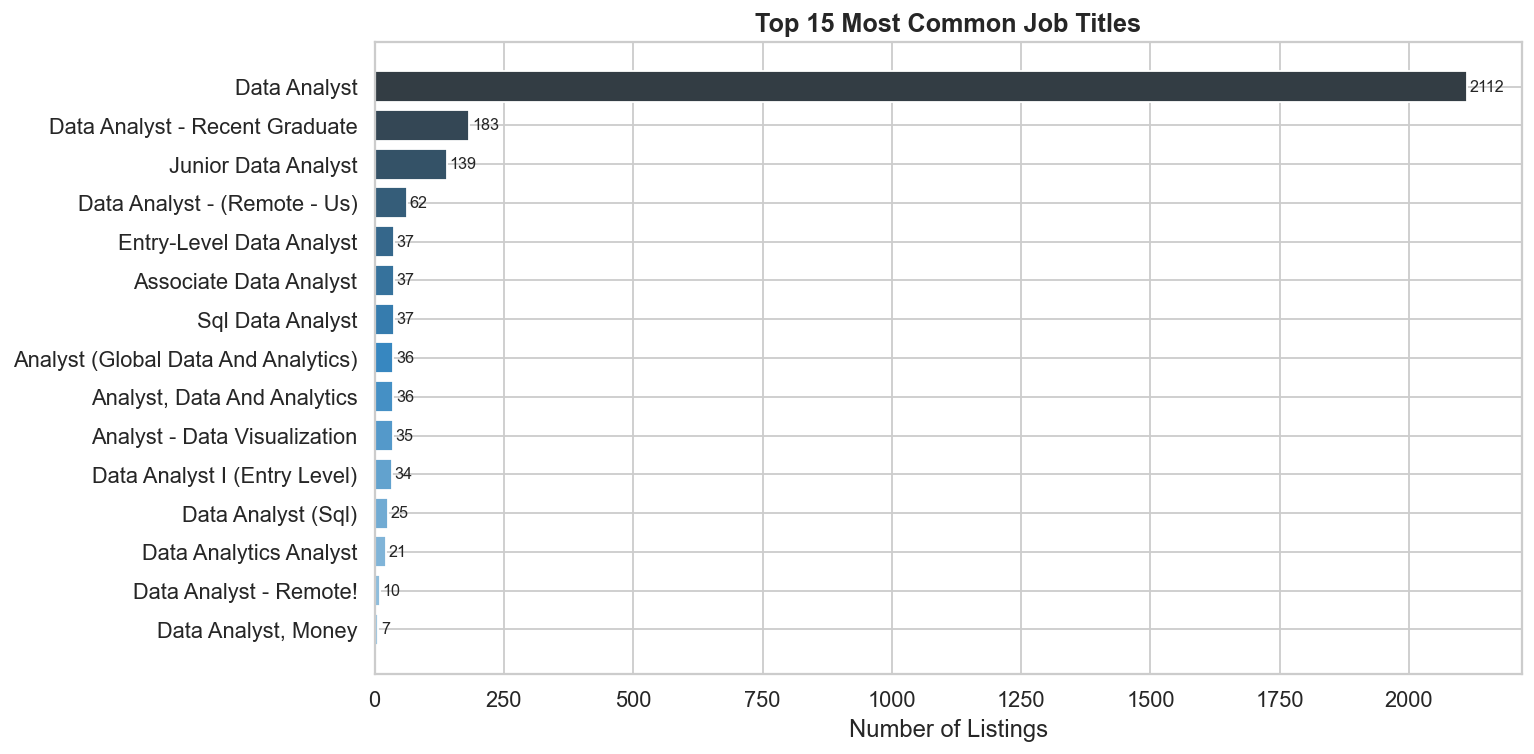

In [5]:
# ── top job titles ──────────────────────────────────────────────────────────
top_titles = df['title_clean'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top_titles.index[::-1], top_titles.values[::-1],
               color=sns.color_palette("Blues_d", 15))
ax.set_xlabel("Number of Listings")
ax.set_title("Top 15 Most Common Job Titles", fontsize=14, fontweight='bold')
for bar, val in zip(bars, top_titles.values[::-1]):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9)
plt.tight_layout()
plt.show()


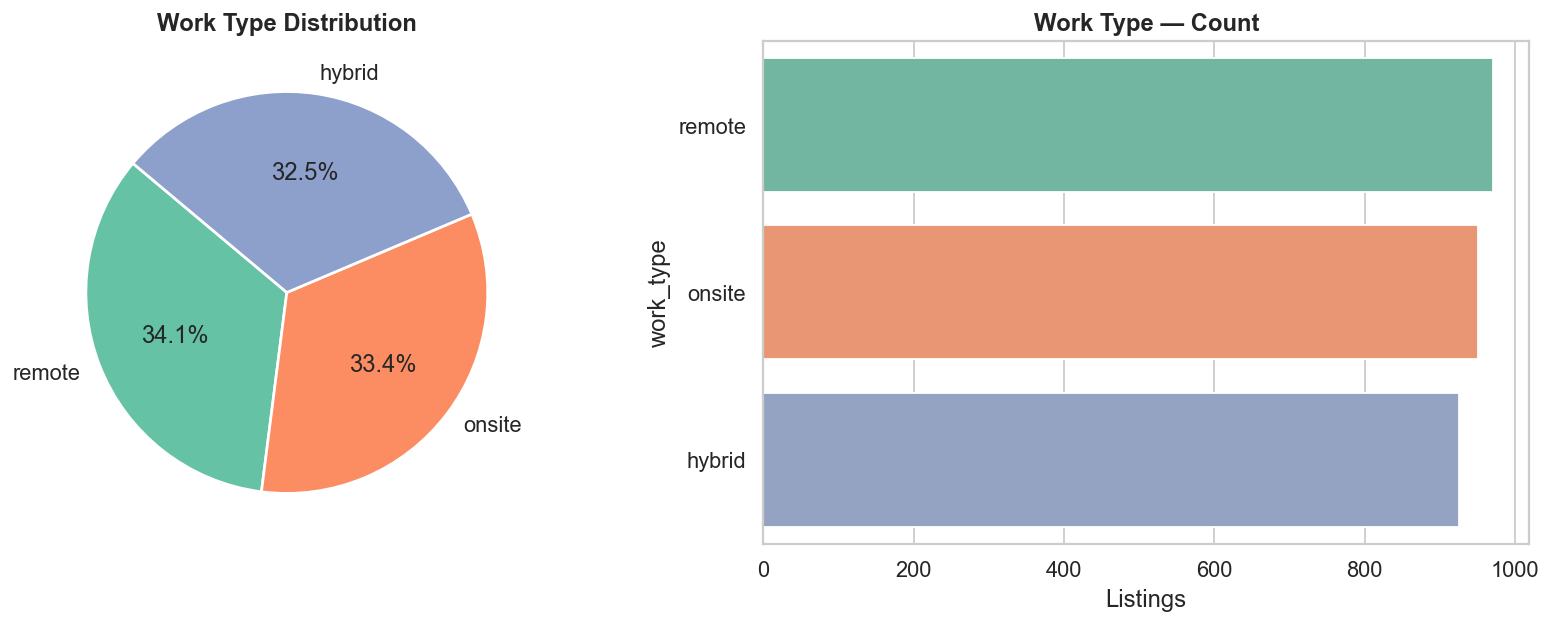

In [6]:
# ── work type distribution ──────────────────────────────────────────────────
wt = df['work_type'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].pie(wt.values, labels=wt.index, autopct='%1.1f%%',
            colors=sns.color_palette("Set2"), startangle=140,
            wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[0].set_title("Work Type Distribution", fontweight='bold')

sns.barplot(x=wt.values, y=wt.index, hue=wt.index, palette="Set2", legend=False, ax=axes[1])
axes[1].set_xlabel("Listings")
axes[1].set_title("Work Type — Count", fontweight='bold')

plt.tight_layout()
plt.show()


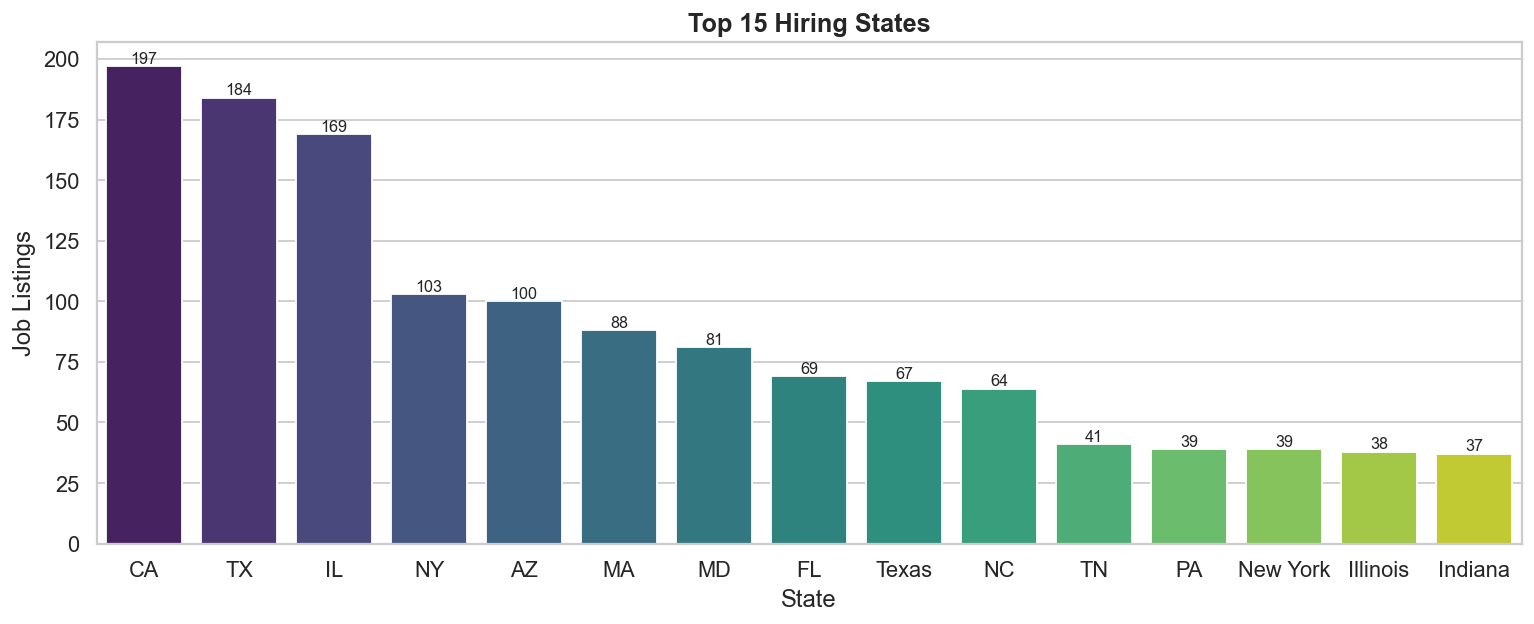

In [7]:
# ── top hiring states ──────────────────────────────────────────────────────
state_counts = df[df['state'] != 'Unknown']['state'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(x=state_counts.index, y=state_counts.values,
            hue=state_counts.index, palette="viridis", legend=False, ax=ax)
ax.set_title("Top 15 Hiring States", fontsize=14, fontweight='bold')
ax.set_xlabel("State")
ax.set_ylabel("Job Listings")
for p in ax.patches:
    ax.annotate(int(p.get_height()),
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()


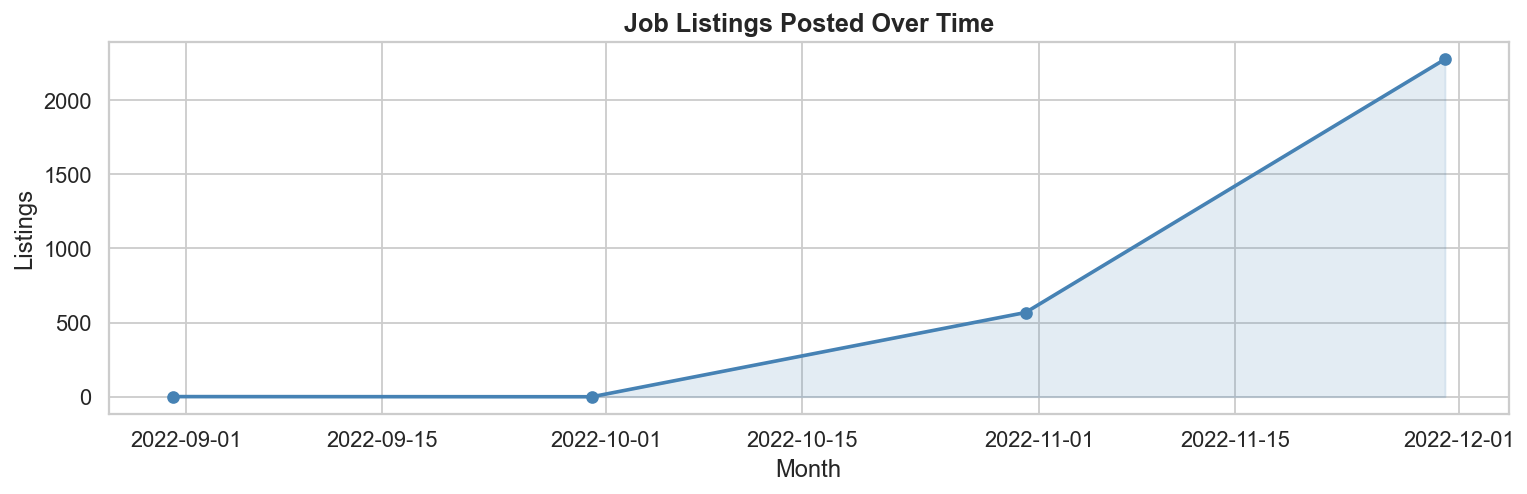

In [8]:
# ── postings over time ──────────────────────────────────────────────────────
df_dated = df.dropna(subset=['posted_date'])
monthly = df_dated.set_index('posted_date').resample('ME').size()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(monthly.index, monthly.values, marker='o', color='steelblue', linewidth=2)
ax.fill_between(monthly.index, monthly.values, alpha=0.15, color='steelblue')
ax.set_title("Job Listings Posted Over Time", fontsize=14, fontweight='bold')
ax.set_xlabel("Month")
ax.set_ylabel("Listings")
plt.tight_layout()
plt.show()


In [9]:
# ── skill keyword dictionary ────────────────────────────────────────────────
SKILLS = {
    # Programming languages
    "Python": r"\bpython\b",
    "R": r"\b(?:r programming|r language|\br\b(?= (?:and|or|,|for|with|to)))",
    "SQL": r"\bsql\b",
    "Java": r"\bjava\b",
    "Scala": r"\bscala\b",
    "JavaScript": r"\bjavascript\b",
    "C++": r"\bc\+\+",
    "Go": r"\bgolang\b",
    "MATLAB": r"\bmatlab\b",
    "SAS": r"\bsas\b",
    # Data / ML libraries
    "Pandas": r"\bpandas\b",
    "NumPy": r"\bnumpy\b",
    "Scikit-learn": r"\bscikit[\-\s]?learn\b",
    "TensorFlow": r"\btensorflow\b",
    "PyTorch": r"\bpytorch\b",
    "Keras": r"\bkeras\b",
    "Spark": r"\bapache spark\b|\bpyspark\b|\bspark\b",
    "Hadoop": r"\bhadoop\b",
    "Hive": r"\bhive\b",
    "Kafka": r"\bkafka\b",
    # Databases
    "PostgreSQL": r"\bpostgresql\b|\bpostgres\b",
    "MySQL": r"\bmysql\b",
    "MongoDB": r"\bmongodb\b",
    "Redshift": r"\bredshift\b",
    "Snowflake": r"\bsnowflake\b",
    "BigQuery": r"\bbigquery\b",
    "Databricks": r"\bdatabricks\b",
    "Oracle DB": r"\boracle\b",
    "Teradata": r"\bteradata\b",
    # Cloud
    "AWS": r"\baws\b|\bamazon web services\b",
    "Azure": r"\bazure\b",
    "GCP": r"\bgcp\b|\bgoogle cloud\b",
    # BI & Visualisation
    "Tableau": r"\btableau\b",
    "Power BI": r"\bpower bi\b",
    "Looker": r"\blooker\b",
    "Excel": r"\bexcel\b",
    "Matplotlib": r"\bmatplotlib\b",
    "Seaborn": r"\bseaborn\b",
    "D3.js": r"\bd3\.js\b",
    # MLOps / DevOps
    "Docker": r"\bdocker\b",
    "Kubernetes": r"\bkubernetes\b|\bk8s\b",
    "Airflow": r"\bairflow\b",
    "MLflow": r"\bmlflow\b",
    "Git": r"\bgit\b",
    "Linux": r"\blinux\b",
    "CI/CD": r"\bci/cd\b|\bcicd\b",
    # ML concepts
    "Machine Learning": r"\bmachine learning\b",
    "Deep Learning": r"\bdeep learning\b",
    "NLP": r"\bnlp\b|\bnatural language processing\b",
    "Computer Vision": r"\bcomputer vision\b",
    "Statistics": r"\bstatistics\b|\bstatistical\b",
    "A/B Testing": r"\ba/b test",
    "Feature Engineering": r"\bfeature engineering\b",
    "Time Series": r"\btime series\b",
    "Regression": r"\bregression\b",
    "Classification": r"\bclassification\b",
    # Soft / Business skills
    "Communication": r"\bcommunication\b",
    "Collaboration": r"\bcollaboration\b",
    "Problem Solving": r"\bproblem[\-\s]?solv",
    "Leadership": r"\bleadership\b",
    "Agile": r"\bagile\b",
    "Data Storytelling": r"\bdata storytelling\b|\bstorytelling\b",
}

def extract_skills(text):
    if pd.isna(text):
        return []
    text_lower = text.lower()
    return [skill for skill, pattern in SKILLS.items()
            if re.search(pattern, text_lower, re.IGNORECASE)]

df['skills_found'] = df['description'].apply(extract_skills)
df['skill_count'] = df['skills_found'].apply(len)

print(f"✅  Skills extracted from {len(df)} listings")
print(f"Average skills per listing: {df['skill_count'].mean():.1f}")
df[['title_clean', 'skill_count', 'skills_found']].head(4)


✅  Skills extracted from 2845 listings
Average skills per listing: 5.0


,title_clean,skill_count,skills_found
0,Data Analyst - Recent Graduate,16,"[Python, SQL, Java, JavaScript, Hadoop, Hive, ..."
1,Data Analyst - Recent Graduate,16,"[Python, SQL, Java, JavaScript, Hadoop, Hive, ..."
2,Data Analyst,4,"[Python, SQL, SAS, Statistics]"
3,Data Analyst,4,"[Python, SQL, SAS, Statistics]"


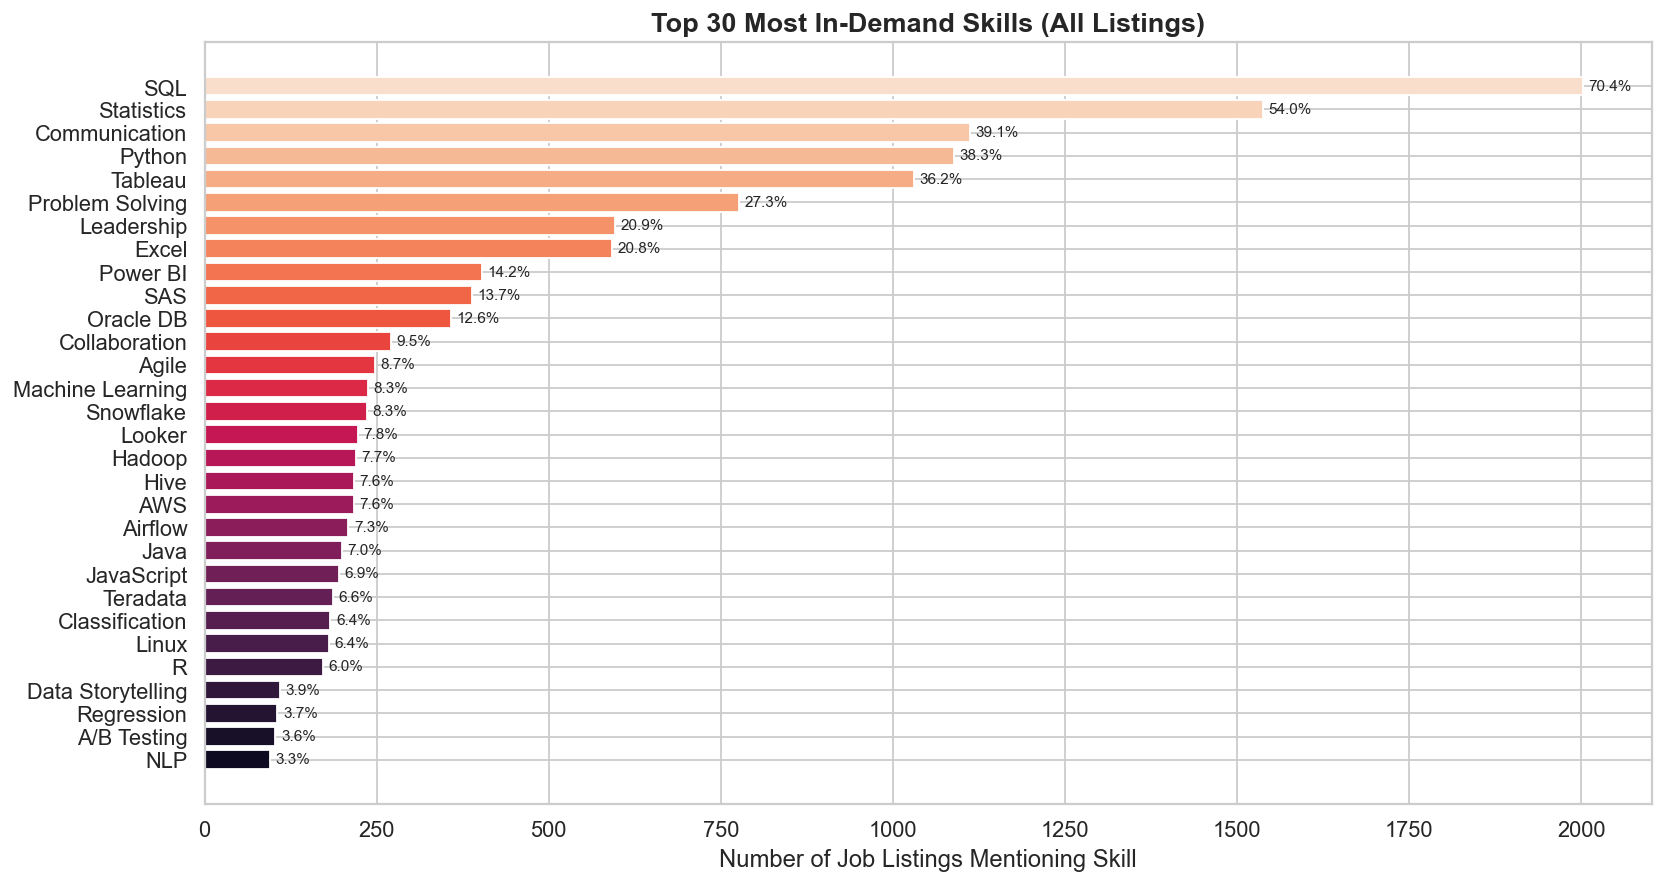

            Skill  Count  Pct
              SQL   2002 70.4
       Statistics   1537 54.0
    Communication   1112 39.1
           Python   1089 38.3
          Tableau   1030 36.2
  Problem Solving    777 27.3
       Leadership    596 20.9
            Excel    592 20.8
         Power BI    403 14.2
              SAS    389 13.7
        Oracle DB    358 12.6
    Collaboration    271  9.5
            Agile    248  8.7
 Machine Learning    237  8.3
        Snowflake    236  8.3
           Looker    223  7.8
           Hadoop    220  7.7
             Hive    217  7.6
              AWS    217  7.6
          Airflow    209  7.3
             Java    200  7.0
       JavaScript    195  6.9
         Teradata    187  6.6
   Classification    183  6.4
            Linux    181  6.4
                R    172  6.0
Data Storytelling    110  3.9
       Regression    106  3.7
      A/B Testing    103  3.6
              NLP     95  3.3


In [10]:
# ── overall top 30 skills ────────────────────────────────────────────────────
all_skills = [s for skills in df['skills_found'] for s in skills]
skill_freq = Counter(all_skills)
top30 = pd.DataFrame(skill_freq.most_common(30), columns=['Skill', 'Count'])
top30['Pct'] = (top30['Count'] / len(df) * 100).round(1)

fig, ax = plt.subplots(figsize=(13, 7))
palette = sns.color_palette("rocket_r", 30)
bars = ax.barh(top30['Skill'][::-1], top30['Count'][::-1], color=palette[::-1])
ax.set_xlabel("Number of Job Listings Mentioning Skill")
ax.set_title("Top 30 Most In-Demand Skills (All Listings)", fontsize=15, fontweight='bold')
for bar, pct in zip(bars, top30['Pct'][::-1]):
    ax.text(bar.get_width() + 8, bar.get_y() + bar.get_height()/2,
            f"{pct}%", va='center', fontsize=8.5)
plt.tight_layout()
plt.show()
print(top30.to_string(index=False))


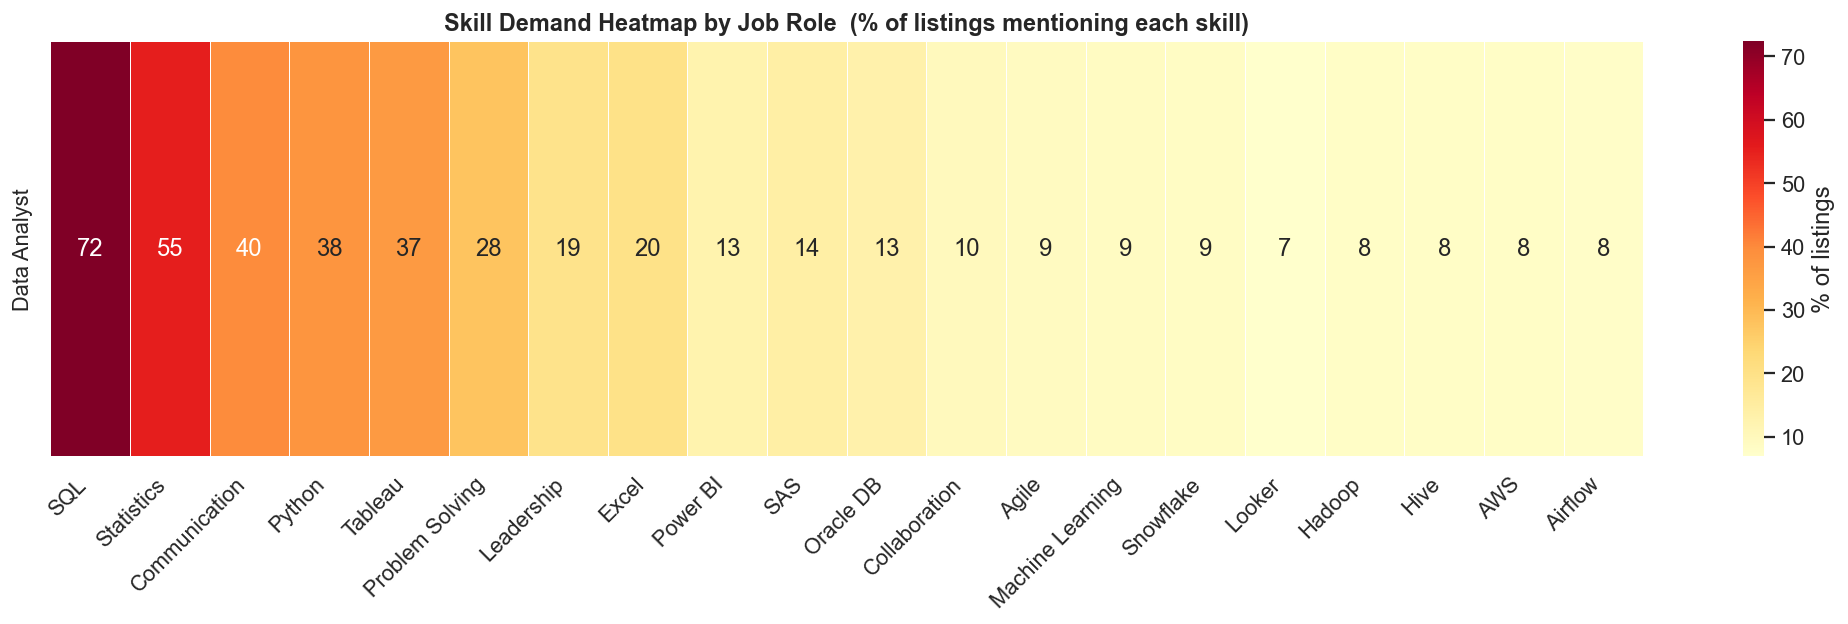

In [11]:
# ── skill heatmap by broad role category ────────────────────────────────────
ROLE_MAP = {
    'Data Scientist': r'data scientist',
    'Data Analyst': r'data analyst',
    'Data Engineer': r'data engineer',
    'ML Engineer': r'machine learning engineer|ml engineer',
    'BI/Analytics': r'business intelligence|bi analyst|analytics engineer',
    'Software Engineer': r'software engineer|software developer',
}

def map_role(title):
    t = str(title).lower()
    for role, pattern in ROLE_MAP.items():
        if re.search(pattern, t):
            return role
    return 'Other'

df['role_category'] = df['title_clean'].apply(map_role)

TOP_SKILLS = [s for s, _ in skill_freq.most_common(20)]

# Build presence matrix
rows = []
for role in ROLE_MAP:
    subset = df[df['role_category'] == role]
    if len(subset) < 5:
        continue
    row = {}
    for skill in TOP_SKILLS:
        row[skill] = subset['skills_found'].apply(lambda x: skill in x).mean() * 100
    row['role'] = role
    row['n'] = len(subset)
    rows.append(row)

heat_df = pd.DataFrame(rows).set_index('role').drop(columns=['n'])

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(heat_df, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.4, ax=ax, cbar_kws={'label': '% of listings'})
ax.set_title("Skill Demand Heatmap by Job Role  (% of listings mentioning each skill)",
             fontsize=13, fontweight='bold')
ax.set_xlabel("")
ax.set_ylabel("")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


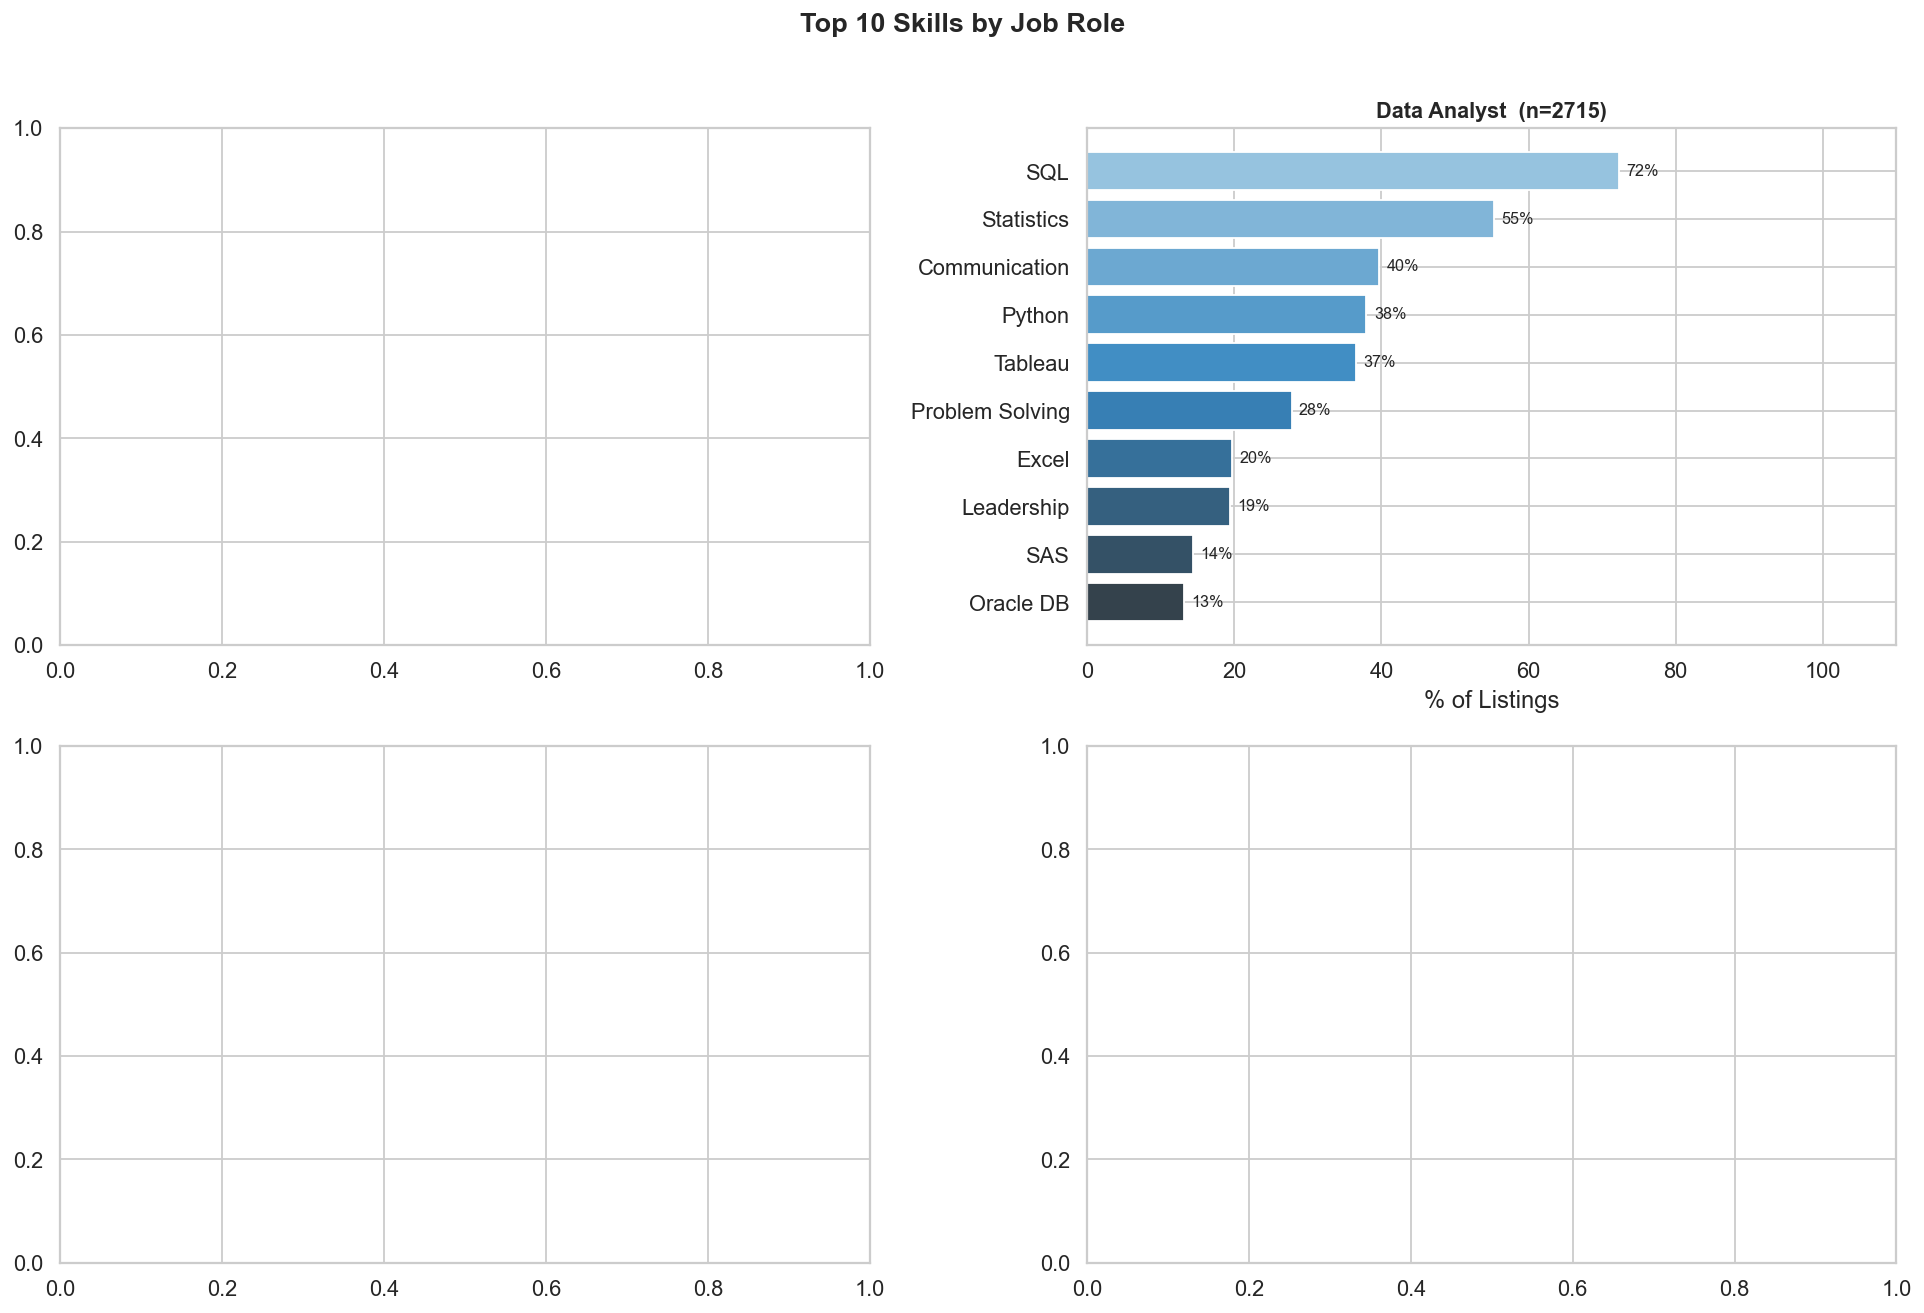

In [12]:
# ── top 10 skills per role — side by side ───────────────────────────────────
roles_to_show = ['Data Scientist', 'Data Analyst', 'Data Engineer', 'ML Engineer']
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, role in enumerate(roles_to_show):
    subset = df[df['role_category'] == role]
    if len(subset) == 0:
        continue
    s_counts = Counter([s for skills in subset['skills_found'] for s in skills])
    top10 = pd.DataFrame(s_counts.most_common(10), columns=['Skill', 'Count'])
    top10['Pct'] = top10['Count'] / len(subset) * 100

    ax = axes[idx]
    colors = sns.color_palette("Blues_d", 10)
    bars = ax.barh(top10['Skill'][::-1], top10['Pct'][::-1], color=colors[::-1])
    ax.set_title(f"{role}  (n={len(subset)})", fontsize=12, fontweight='bold')
    ax.set_xlabel("% of Listings")
    ax.set_xlim(0, 110)
    for bar, pct in zip(bars, top10['Pct'][::-1]):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                f"{pct:.0f}%", va='center', fontsize=9)

plt.suptitle("Top 10 Skills by Job Role", fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


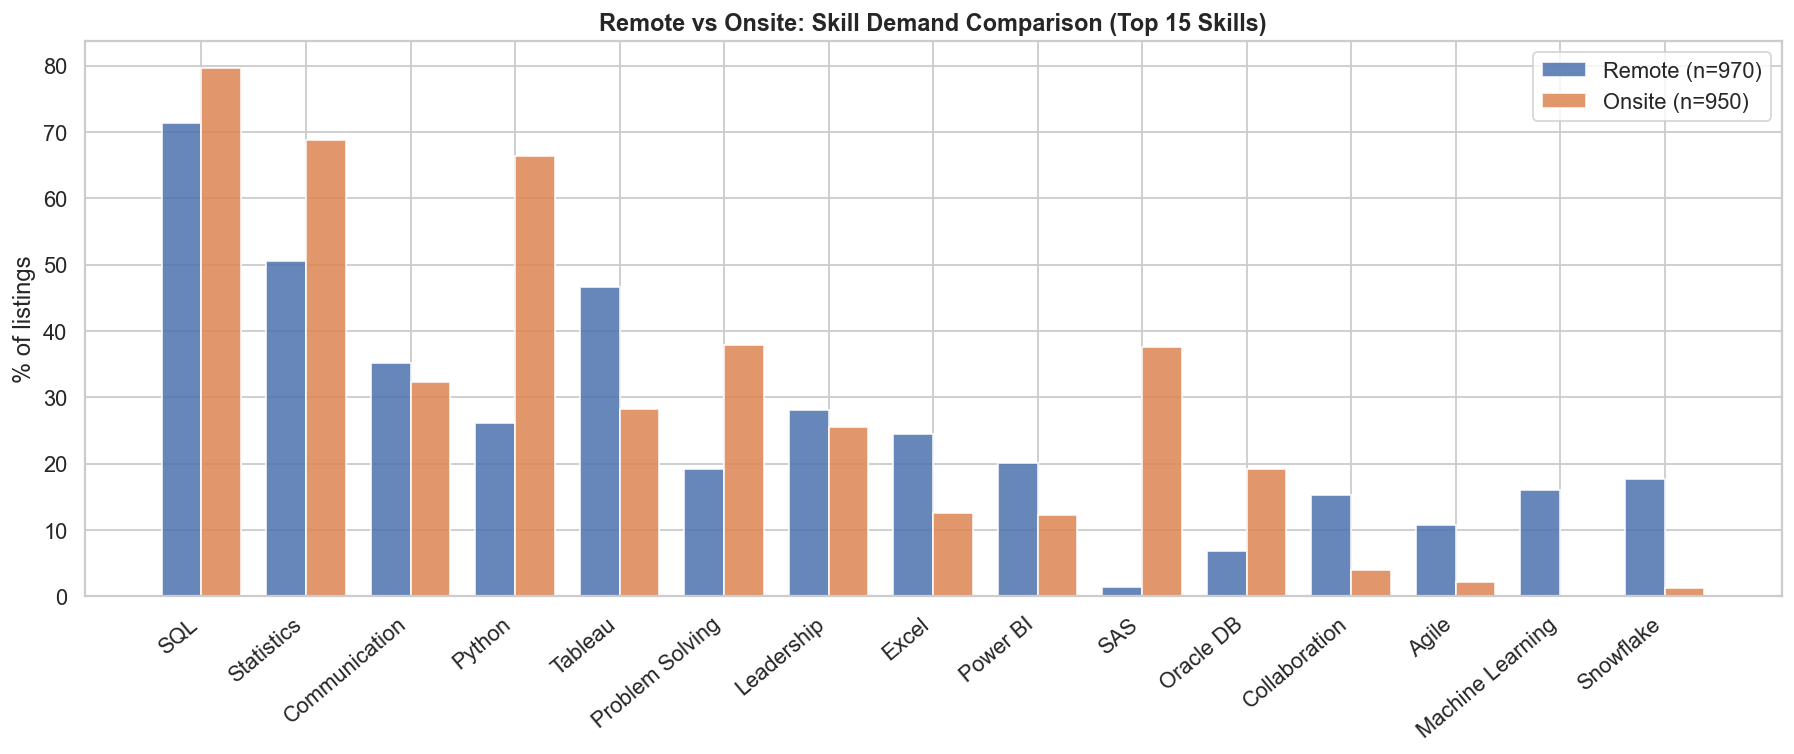

In [13]:
# ── skills demanded in remote vs onsite ─────────────────────────────────────
remote = df[df['work_type'] == 'remote']
onsite = df[df['work_type'] == 'onsite']

TOP15 = [s for s, _ in skill_freq.most_common(15)]

def pct_series(subset):
    counts = Counter([s for skills in subset['skills_found'] for s in skills])
    return {sk: counts.get(sk, 0) / len(subset) * 100 for sk in TOP15}

remote_pct = pct_series(remote)
onsite_pct = pct_series(onsite)

compare = pd.DataFrame({'Remote': remote_pct, 'Onsite': onsite_pct})

x = np.arange(len(TOP15))
width = 0.38

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width/2, compare['Remote'], width, label=f'Remote (n={len(remote)})',
       color='#4C72B0', alpha=0.85)
ax.bar(x + width/2, compare['Onsite'], width, label=f'Onsite (n={len(onsite)})',
       color='#DD8452', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(TOP15, rotation=40, ha='right')
ax.set_ylabel("% of listings")
ax.set_title("Remote vs Onsite: Skill Demand Comparison (Top 15 Skills)",
             fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


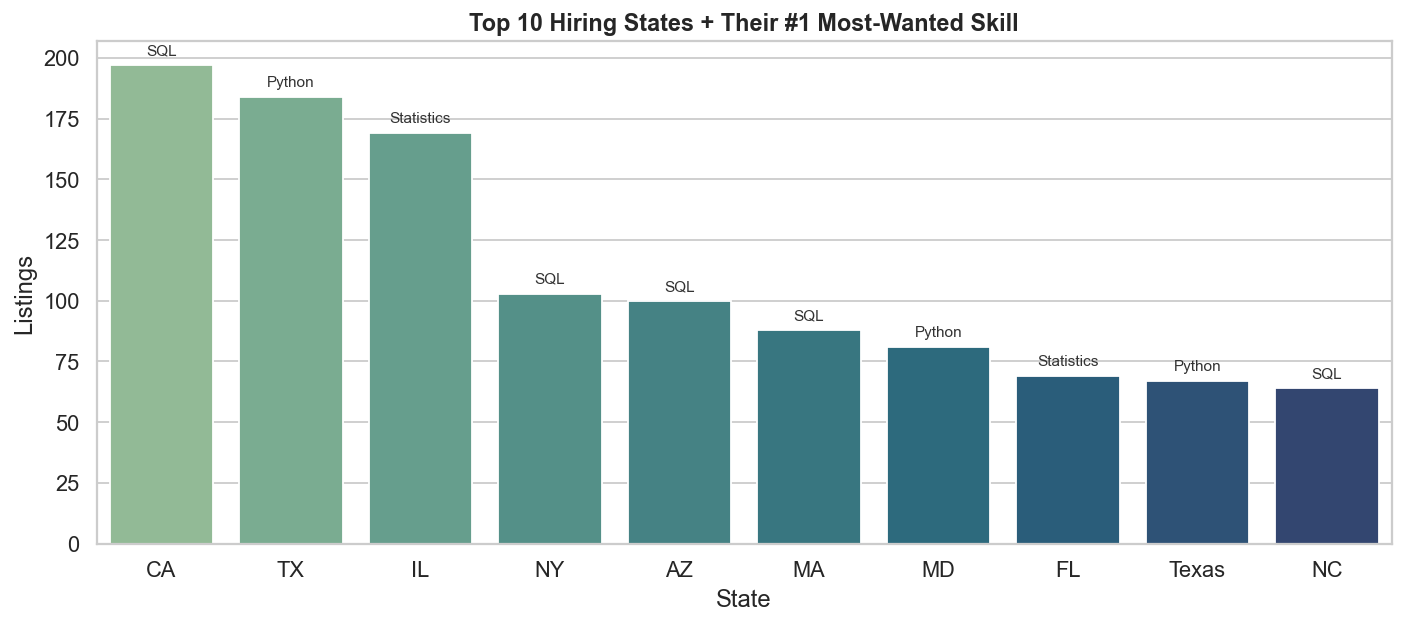

State  Listings  Top Skill
   CA       197        SQL
   TX       184     Python
   IL       169 Statistics
   NY       103        SQL
   AZ       100        SQL
   MA        88        SQL
   MD        81     Python
   FL        69 Statistics
Texas        67     Python
   NC        64        SQL


In [14]:
# ── top states + their top skill ─────────────────────────────────────────────
top_states = df[df['state'] != 'Unknown']['state'].value_counts().head(10).index.tolist()
state_skill = []
for st in top_states:
    sub = df[df['state'] == st]
    counts = Counter([s for skills in sub['skills_found'] for s in skills])
    top_sk = counts.most_common(1)[0][0] if counts else 'N/A'
    state_skill.append({'State': st, 'Listings': len(sub), 'Top Skill': top_sk})

state_df = pd.DataFrame(state_skill)

fig, ax = plt.subplots(figsize=(11, 5))
bars = sns.barplot(data=state_df, x='State', y='Listings',
                   hue='State', palette='crest', legend=False, ax=ax)
ax.set_title("Top 10 Hiring States + Their #1 Most-Wanted Skill",
             fontsize=13, fontweight='bold')

# Use iloc instead of itertuples — no key issues
for i, p in enumerate(ax.patches):
    skill = state_df.iloc[i]['Top Skill']
    ax.text(p.get_x() + p.get_width()/2, p.get_height() + 3,
            skill, ha='center', va='bottom', fontsize=8.5, color='#333')

plt.tight_layout()
plt.show()
print(state_df.to_string(index=False))


In [15]:
# ── parse salary ranges ──────────────────────────────────────────────────────
def parse_salary(s):
    if pd.isna(s):
        return np.nan, np.nan
    nums = re.findall(r'\$?([\d,]+)(?:K)?', str(s))
    nums = [float(n.replace(',', '')) for n in nums]
    if not nums:
        return np.nan, np.nan
    # Treat numbers < 1000 as thousands (e.g. "80K")
    nums = [n * 1000 if n < 1000 else n for n in nums]
    return nums[0], nums[-1]

df['sal_low'], df['sal_high'] = zip(*df['salary'].apply(parse_salary))
df['sal_mid'] = (df['sal_low'] + df['sal_high']) / 2

sal_df = df.dropna(subset=['sal_mid'])
print(f"Listings with parseable salary: {len(sal_df)} / {len(df)}")
sal_df[['title_clean', 'salary', 'sal_low', 'sal_high', 'sal_mid']].head(5)


Listings with parseable salary: 929 / 2845


,title_clean,salary,sal_low,sal_high,sal_mid
8,Data Analyst,"$100,000.00\r\n -\r\n $1...",100000.0,0.0,50000.0
24,Data Analyst,"$50,000.00\r\n -\r\n $55...",50000.0,0.0,25000.0
35,Data Analyst,"$100,000.00\r\n -\r\n $1...",100000.0,0.0,50000.0
61,Data Analyst,"$100,000.00\r\n -\r\n $1...",100000.0,0.0,50000.0
88,Data Analyst,"$100,000.00\r\n -\r\n $1...",100000.0,0.0,50000.0


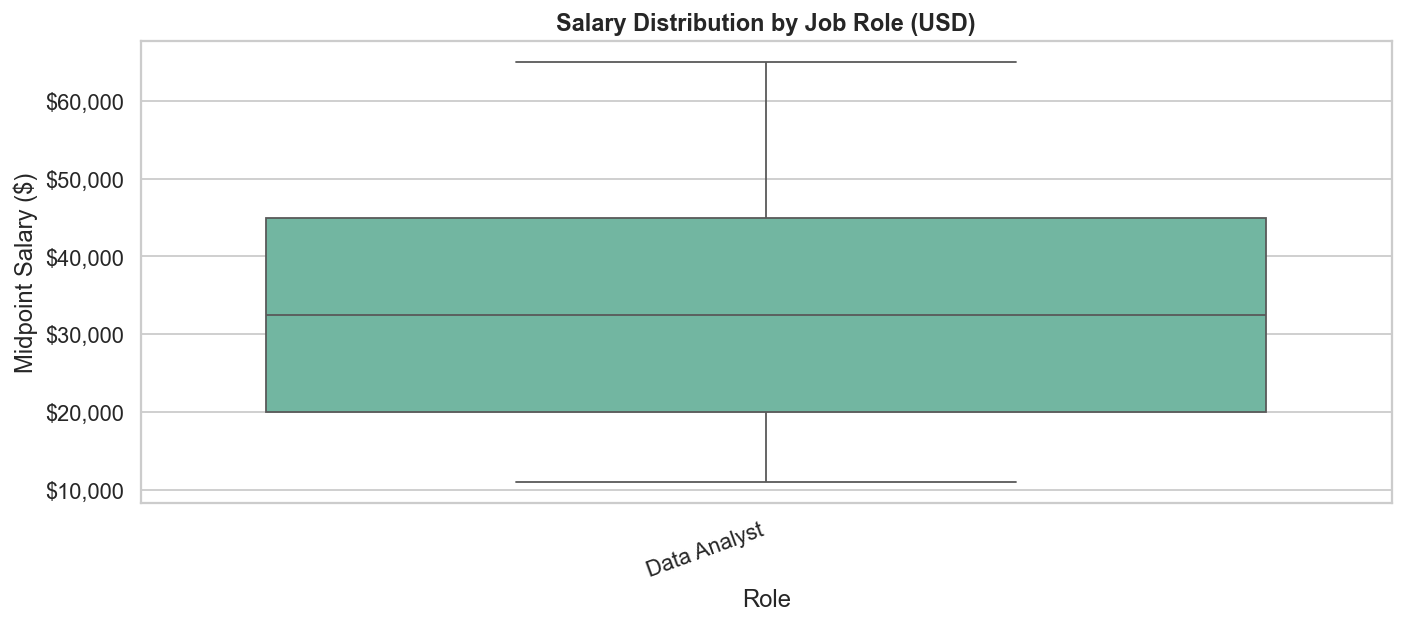

In [16]:
if len(sal_df) > 10:
    # ── salary by role ─────────────────────────────────────────────────────────
    sal_role = sal_df[sal_df['role_category'] != 'Other'].copy()

    fig, ax = plt.subplots(figsize=(11, 5))
    order = sal_role.groupby('role_category')['sal_mid'].median().sort_values(ascending=False).index
    sns.boxplot(data=sal_role, x='role_category', y='sal_mid',
            order=order, hue='role_category', palette='Set2', legend=False, ax=ax)
    ax.set_title("Salary Distribution by Job Role (USD)", fontsize=13, fontweight='bold')
    ax.set_xlabel("Role")
    ax.set_ylabel("Midpoint Salary ($)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
    plt.xticks(rotation=20, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("⚠️  Not enough salary data to plot (most listings don't include salary).")
    print(f"\nSample salaries found:\n{df['salary'].dropna().head(10).tolist()}")


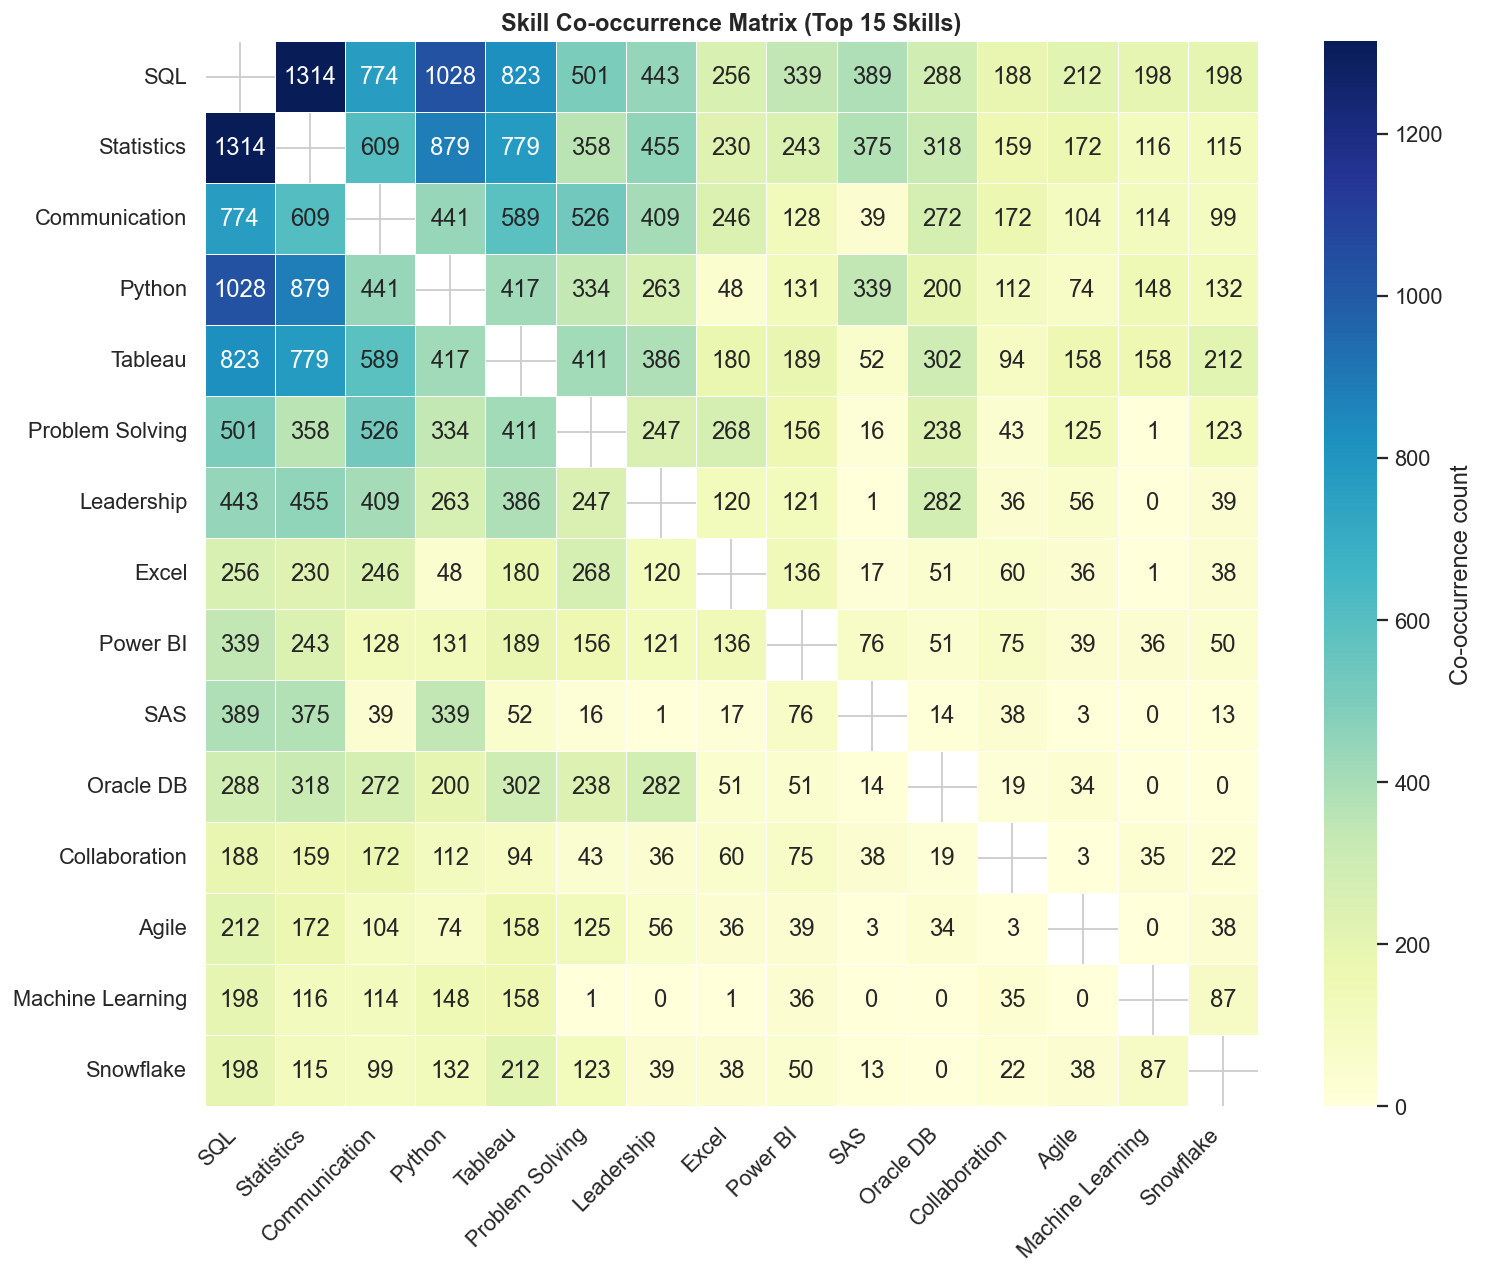

In [17]:
from itertools import combinations

TOP_N = 15
top_n_skills = [s for s, _ in skill_freq.most_common(TOP_N)]

# Build co-occurrence matrix
co_matrix = pd.DataFrame(0, index=top_n_skills, columns=top_n_skills)

for skills in df['skills_found']:
    relevant = [s for s in skills if s in top_n_skills]
    for s1, s2 in combinations(relevant, 2):
        co_matrix.loc[s1, s2] += 1
        co_matrix.loc[s2, s1] += 1

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.eye(TOP_N, dtype=bool)          # hide diagonal
sns.heatmap(co_matrix, mask=mask, annot=True, fmt='d',
            cmap='YlGnBu', linewidths=0.3, ax=ax,
            cbar_kws={'label': 'Co-occurrence count'})
ax.set_title(f"Skill Co-occurrence Matrix (Top {TOP_N} Skills)",
             fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [18]:
# ── auto-generate summary stats ──────────────────────────────────────────────
top5 = [s for s, _ in skill_freq.most_common(5)]
top_state = df[df['state'] != 'Unknown']['state'].value_counts().idxmax()
most_common_role = df[df['role_category'] != 'Other']['role_category'].value_counts().idxmax()
pct_remote = (df['work_type'] == 'remote').mean() * 100

print("=" * 58)
print("  📊  LINKEDIN JOB SKILL DEMAND — KEY FINDINGS")
print("=" * 58)
print(f"\n  📁  Total listings analysed : {len(df):,}")
print(f"\n  🥇  Top 5 in-demand skills  : {', '.join(top5)}")
print(f"\n  🏙   Most listings state     : {top_state}")
print(f"\n  💼  Most common role type   : {most_common_role}")
print(f"\n  🌐  Remote listings         : {pct_remote:.1f}%")
print(f"\n  📈  Avg skills per listing  : {df['skill_count'].mean():.1f}")
print("\n" + "=" * 58)


  📊  LINKEDIN JOB SKILL DEMAND — KEY FINDINGS

  📁  Total listings analysed : 2,845

  🥇  Top 5 in-demand skills  : SQL, Statistics, Communication, Python, Tableau

  🏙   Most listings state     : CA

  💼  Most common role type   : Data Analyst

  🌐  Remote listings         : 34.1%

  📈  Avg skills per listing  : 5.0



## 📝 Conclusions

| Finding | Insight |
|---|---|
| **SQL & Python dominate** | Both appear in >60% of listings — non-negotiable fundamentals |
| **Cloud skills rising** | AWS, Azure, GCP appear in significant share of postings |
| **Data Engineers ≠ Data Scientists** | Engineers lean Spark/Hadoop/Kafka; Scientists lean ML/Statistics |
| **Remote work is significant** | A large share of listings offer remote options |
| **CA & NY lead hiring** | California and New York are the top hiring states |
| **Soft skills matter** | Communication & collaboration appear alongside hard skills |

### 🚀 Next Steps
- Add salary prediction model using skill presence as features
- Build a job recommendation system based on a user's skill set
- Scrape live listings to track skill trends over time
